In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np

data_path = "/content/drive/MyDrive/NIDS/NIDS_processed_data"

X_train = np.load(f"{data_path}/X_train_final.npy")
X_test = np.load(f"{data_path}/X_test_final.npy")

y_train = np.load(f"{data_path}/y_train_encoded.npy")
y_test = np.load(f"{data_path}/y_test_encoded.npy")

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (1785444, 55)
Testing data: (446362, 55)
Training target: (1785444,)
Testing target: (446362,)


In [4]:
print("NaN values in X_train:", np.isnan(X_train).sum())
print("NaN values in X_test :", np.isnan(X_test).sum())

print("Infinite values in X_train:", np.isinf(X_train).sum())
print("Infinite values in X_test :", np.isinf(X_test).sum())

NaN values in X_train: 0
NaN values in X_test : 0
Infinite values in X_train: 0
Infinite values in X_test : 0


In [5]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

print("Random Forest model created.")

Random Forest model created.


In [6]:
import time

print("Starting Random Forest training...")

start_time = time.time()

rf_model.fit(X_train, y_train)

training_time = time.time() - start_time

print("Training completed.")
print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time / 60:.2f} minutes")

Starting Random Forest training...
Training completed.
Training time: 838.84 seconds
Training time: 13.98 minutes


In [7]:
print("Generating Random Forest predictions...")

y_pred_rf = rf_model.predict(X_test)

print("Prediction completed.")
print("Predictions shape:", y_pred_rf.shape)

Generating Random Forest predictions...
Prediction completed.
Predictions shape: (446362,)


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision_macro = precision_score(
    y_test, y_pred_rf,
    average="macro",
    zero_division=0
)

rf_recall_macro = recall_score(
    y_test, y_pred_rf,
    average="macro",
    zero_division=0
)

rf_f1_macro = f1_score(
    y_test, y_pred_rf,
    average="macro",
    zero_division=0
)

rf_f1_weighted = f1_score(
    y_test, y_pred_rf,
    average="weighted",
    zero_division=0
)

print("Random Forest Results")
print("-" * 35)
print(f"Accuracy       : {rf_accuracy:.4f}")
print(f"Macro Precision: {rf_precision_macro:.4f}")
print(f"Macro Recall   : {rf_recall_macro:.4f}")
print(f"Macro F1       : {rf_f1_macro:.4f}")
print(f"Weighted F1    : {rf_f1_weighted:.4f}")

Random Forest Results
-----------------------------------
Accuracy       : 0.9985
Macro Precision: 0.9234
Macro Recall   : 0.8104
Macro F1       : 0.8429
Weighted F1    : 0.9985


In [10]:
import joblib

label_encoder = joblib.load("/content/drive/MyDrive/NIDS/NIDS_processed_data/label_encoder.pkl")

print("Label encoder loaded.")
print("Classes:", label_encoder.classes_)

Label encoder loaded.
Classes: ['Benign' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']


In [11]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report")
print("-" * 70)

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Random Forest Classification Report
----------------------------------------------------------------------
                            precision    recall  f1-score   support

                    Benign       1.00      1.00      1.00    379064
                       Bot       0.83      0.62      0.71       288
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       1.00      1.00      1.00      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.95      0.99      0.97      1046
             DoS slowloris       1.00      1.00      1.00      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      0.50      0.67         2
              Infiltration       1.00      0.86      0.92         7
                  PortScan       0.94      0.92      0.93       391
               SSH-Patator       1.00      0.98      0.99       644
  Web At

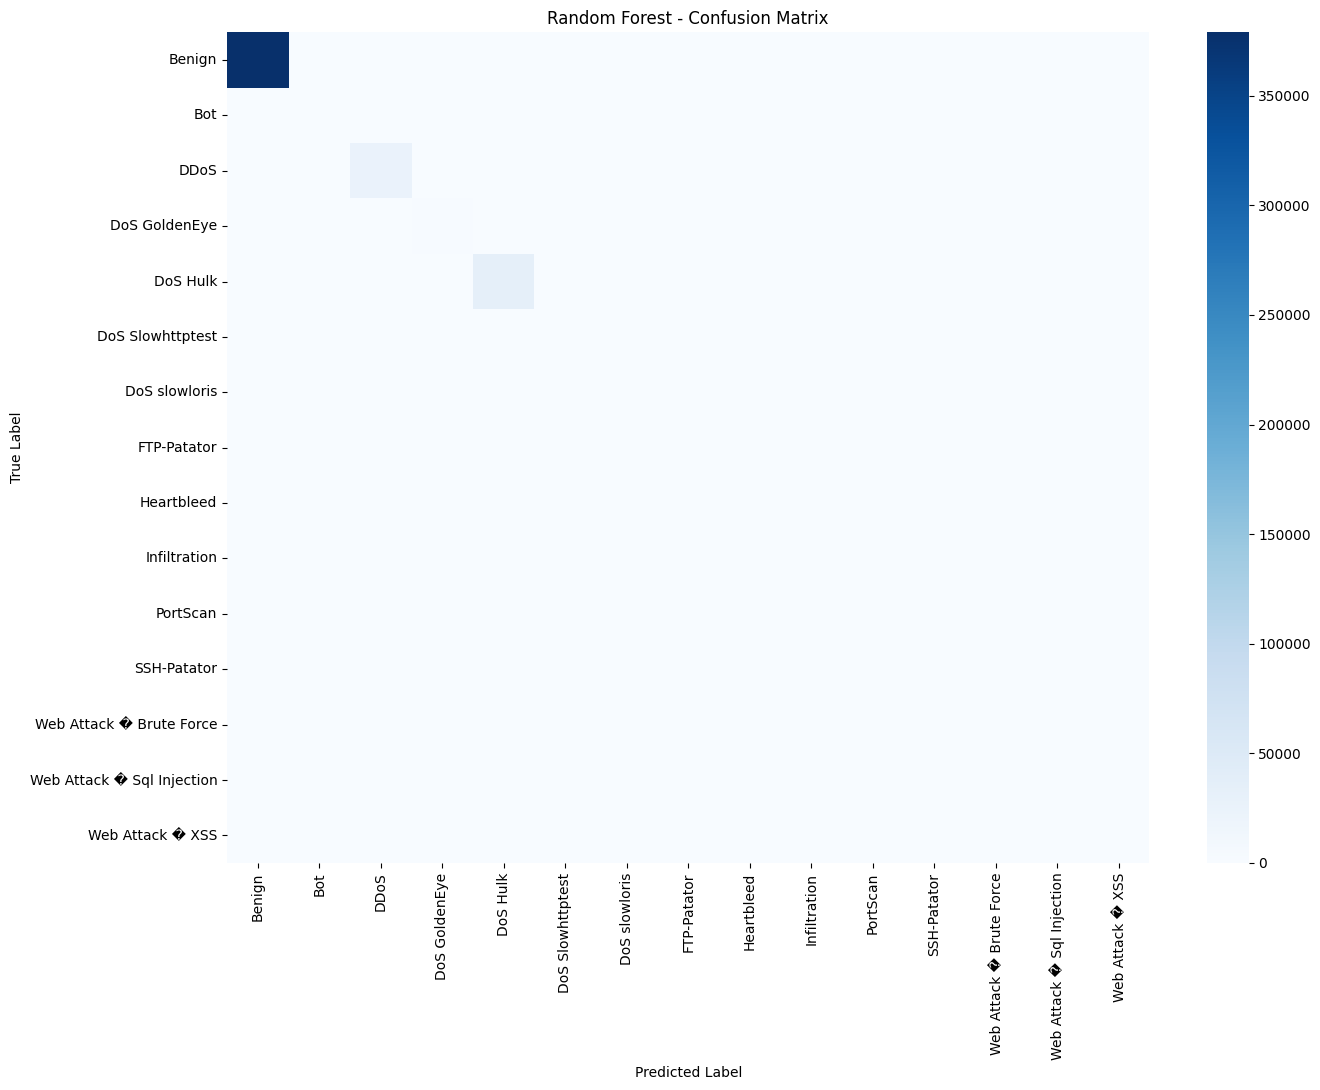

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(14, 11))

sns.heatmap(
    cm_rf,
    annot=False,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest - Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
import os
import joblib
import json

os.makedirs("/content/drive/MyDrive/NIDS/models", exist_ok=True)
os.makedirs("/content/drive/MyDrive/NIDS/results", exist_ok=True)

# Save trained Random Forest model
joblib.dump(
    rf_model,
    "/content/drive/MyDrive/NIDS/models/random_forest.pkl"
)

# Save evaluation metrics
rf_results = {
    "model": "Random Forest",
    "accuracy": rf_accuracy,
    "macro_precision": rf_precision_macro,
    "macro_recall": rf_recall_macro,
    "macro_f1": rf_f1_macro,
    "weighted_f1": rf_f1_weighted,
    "training_time_seconds": training_time
}

with open(
    "/content/drive/MyDrive/NIDS/results/random_forest_metrics.json",
    "w"
) as f:
    json.dump(rf_results, f, indent=4)

print("Random Forest model saved.")
print("Random Forest metrics saved.")

Random Forest model saved.
Random Forest metrics saved.
